In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

(52, 4)
  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming
latitude     39.435516
longitude   -89.093198
dtype: float64
The closest state to median latitude is Colorado, off by 0.11 degrees
The furthest state from median latitude is Alaska, off by 24.15 degrees
The closest state to median longitude is Illinois, off by 0.31 degrees
The furthest state to median longitude is Hawaii, off by 66.57 degrees
(498, 6)
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1      

C:\Users\evdan\AppData\Local\Temp\ipykernel_26872\4268512334.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


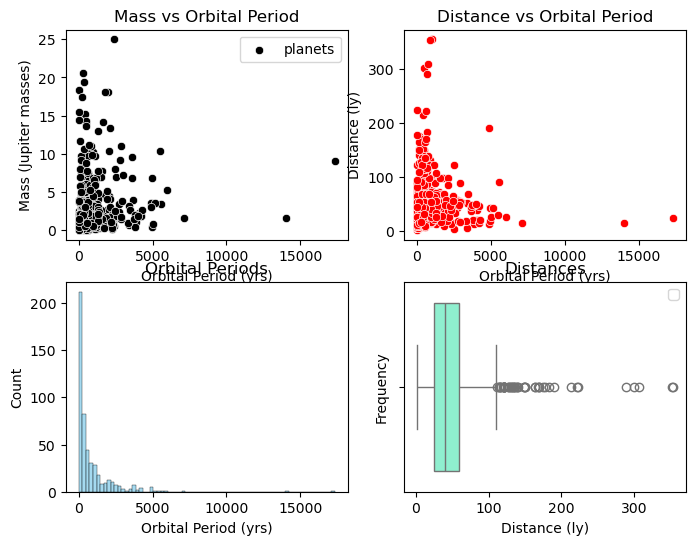

In [79]:
states = pd.read_csv("../../course_assignments/homework8/state_data.csv")
print(states.shape)
print(states.head(5))
print(states.tail(5))
#The columns are: index, state abbreviation, latitude, longitude, and official name
#The first state is Alaska, the last state is Wyoming.
#There are 52 entries.
#DC and Puerto Rico are included.
print(states.median(numeric_only = True))
#Median latitude: 39.435516, median longitude: -89.093198
latitude_error_series = abs(states["latitude"] - 39.435516)
longitude_error_series = abs(states["longitude"] + 89.093198)
states["latitude_error"] = latitude_error_series
states["longitude_error"] = longitude_error_series
#print(states["latitude_error"].idxmin())
print(f"The closest state to median latitude is {states.iat[states["latitude_error"].idxmin(), 3]}, off by {states.iat[states["latitude_error"].idxmin(), 4]:.2f} degrees")
print(f"The furthest state from median latitude is {states.iat[states["latitude_error"].idxmax(), 3]}, off by {states.iat[states["latitude_error"].idxmax(), 4]:.2f} degrees")
print(f"The closest state to median longitude is {states.iat[states["longitude_error"].idxmin(), 3]}, off by {states.iat[states["longitude_error"].idxmin(), 5]:.2f} degrees")
print(f"The furthest state to median longitude is {states.iat[states["longitude_error"].idxmax(), 3]}, off by {states.iat[states["longitude_error"].idxmax(), 5]:.2f} degrees")

bin = [0, 10, 20, 30, 40, 50, 60, 70]
error_categories = pd.cut(states["longitude_error"], bins = bin)
#print(error_categories)
#I found this on the documentation for pandas on pydata.org
#This bins categories so that intervals can be made for distances and groups can be separated.

dataset = sns.load_dataset("planets")
planets = dataset.dropna()
print(planets.shape)
#dataset with 498 rows, 6 columns
print(planets.head(5))
print(planets.tail(5))
#column names: index, method (how was it detected), number (how many planets are in the system), orbital_period (time to revolve), mass (Jupiter masses)
#distance (light-years from Earth), year (year discovered)
fig, axes = plt.subplots(2,2, figsize = (8,6))
sns.scatterplot(x = planets["orbital_period"], y = planets["mass"], data = planets, ax=axes[0, 0], label = "planets", c = "black")
sns.scatterplot(x = planets["orbital_period"], y = planets["distance"], data = planets, ax=axes[0, 1], c = "red")
sns.histplot(x = planets["orbital_period"], data = planets, ax=axes[1, 0], color = "skyblue")
sns.boxplot(x = planets["distance"], data = planets, ax=axes[1, 1], color = "aquamarine")

axes[0,0].set_xlabel("Orbital Period (yrs)")
axes[0,0].set_ylabel("Mass (Jupiter masses)")
axes[0,0].set_title("Mass vs Orbital Period")
axes[0,1].set_xlabel("Orbital Period (yrs)")
axes[0,1].set_ylabel("Distance (ly)")
axes[0,1].set_title("Distance vs Orbital Period")
axes[1,0].set_xlabel("Orbital Period (yrs)")
axes[1,0].set_title("Orbital Periods")
axes[1,1].set_xlabel("Distance (ly)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].set_title("Distances")

plt.legend()
plt.show()

#The top left plot is a comparison of the orbital period and the mass of a planet, and data may indicate that low mass objects are capable of having very high orbital periods.
#The top right graph shows a comparison of orbital period with distance from Earth, which would be helpful for determining which exoplanets are close/far enough to their star and still close enough to observe in more detail.
#The bottom left graph shows a list of all orbital periods and their frequencies, which may help with coming up with models for how exoplanets form, as lower orbital periods seem much more common than higher ones.
#The last graph shows a box and whisker plot of all distances from Earth, which show how many planets are close enough to Earth to analyze in more detail.